# Results of SPARC segmentation experiments

This notebook reproduces the statistical analysis of the deep-learning segmentation networks (chest and heart) trained across Philips (source) and Siemens (target) domains: source-only, joint, and transfer-learning conditions, ensemble vs. individual-model prediction, and comparison against inter-rater agreement.

Part of the `sparc` package, by Arnaud Boutillon (arnaud.boutillon@kcl.ac.uk)

**On data.** This notebook operates on `csv/*_seg_*.csv` and `csv/cohort.csv`, de-identified, subject-level tables of segmentation metrics, not raw imaging data.

## Setup

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from scipy.stats import ttest_rel
from scipy.spatial.transform import Rotation

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")

notebook_dir = os.path.abspath("./")
csv_dir = os.path.join(notebook_dir, "csv")
plot_dir = os.path.join(notebook_dir, "plot")

## Utilities

- `load_df`, loads and concatenates one `<roi>_seg_<domain>.csv` per condition.
- `convert_pvalue_to_asterisks`, standard significance-stars convention.
- `plot_metrics`, shared strip-plot-with-significance-brackets figure.

In [2]:
def load_df(csv_dir, domain_col, domains, domains_labels, roi):
    """Load and concatenate one <roi>_seg_<domain>.csv per condition,
    labelling each with domains_labels[i] under domain_col.
    """
    dfs = []
    for i, (domain, domain_label) in enumerate(zip(domains, domains_labels)):
        if domain is None:
            continue
        else:
            domain_df_path = os.path.join(csv_dir, f"{roi}_seg_{domain}.csv")
            domain_df = pd.read_csv(domain_df_path)
            domain_df[domain_col] = domain_label
            dfs.append(domain_df)

    df = pd.concat(dfs, ignore_index=True)
    return df

In [3]:
def convert_pvalue_to_asterisks(pvalue):
    """Standard significance-stars convention: **** <=0.0001,
    *** <=0.001, ** <=0.01, * <=0.05, else "ns" (not significant)."""
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

In [4]:
def paired_arrays(df, domain_col, groups_col, g1, g2, metric_col):
    """Extract metric_col for domains g1/g2, sorted and verified to
    correspond to the same subjects."""
    df1 = df[df[domain_col] == g1].sort_values(groups_col)
    df2 = df[df[domain_col] == g2].sort_values(groups_col)
    assert list(df1[groups_col]) == list(df2[groups_col]), (
        f"Subject mismatch between '{g1}' and '{g2}' for {metric_col} -- "
        "paired comparison requires identical, correspondingly-ordered subjects."
    )
    return df1[metric_col], df2[metric_col]


def plot_metrics(dfs, stats="ttest"):
    """Strip-plot of each metric (rows) across domains (columns of
    subplots = source/target dataframes passed in), annotated with
    per-group mean +/- std and pairwise significance brackets, using
    either a paired t-test (stats="ttest") or a linear mixed-effects
    model with subject_id as random-effects group (stats="lme"), both
    Bonferroni-corrected for the number of comparisons drawn per panel.
    """
    fig, axes = plt.subplots(len(metric_labels), 2, figsize=(10.5, len(metric_labels)*2.25), sharey="row")
    fig.suptitle(title)

    for i, (df, _domains, _domains_labels, _comparisons) in enumerate(zip(dfs, domains, domains_labels, comparisons)):
        for j, (metric_col, metric_label) in enumerate(zip(metric_cols, metric_labels)):
            np.random.seed(42)
            sns.stripplot(ax=axes[j,i], data=df, x=domain_col, y=metric_col, hue=domain_col, alpha=0.8, legend=False)
            y_range = y_lims[j][1] - y_lims[j][0]

            # Per-group mean +/- std annotation
            for k, (domain, domain_label) in enumerate(zip(_domains, _domains_labels)):
                if domain is None:
                    continue
                group = df[df[domain_col] == domain_label][metric_col]
                mean = group.mean()
                std = group.std()
                axes[j,i].text(k, group.min() - 0.1*y_range, f"{mean:.2f} \u00b1 {std:.2f}", ha="center", va="center", fontsize=10)

            # Pairwise significance, Bonferroni-corrected across the
            # comparisons drawn in this panel.
            l = 0
            for k, (g1, g2) in enumerate(_comparisons):
                if stats == "ttest":
                    y1, y2 = paired_arrays(df, domain_col, groups_col, g1, g2, metric_col)
                    stat, p = ttest_rel(y1, y2)
                    stars = convert_pvalue_to_asterisks(p * len(_comparisons))  # Bonferroni correction
                elif stats == "lme":
                    formula = f"{metric_col} ~ C({domain_col}, Treatment('{g1}'))"
                    _df = df[(df[domain_col] == g1) | (df[domain_col] == g2)]
                    lme_model = smf.mixedlm(formula=formula, data=_df, groups=_df[groups_col]).fit(reml=False)
                    p = lme_model.pvalues[f"C({domain_col}, Treatment('{g1}'))[T.{g2}]"]
                    stars = convert_pvalue_to_asterisks(p * len(_comparisons))  # Bonferroni correction

                if stars == "ns":
                    continue
                # Bracket annotation
                x1 = _domains_labels.index(g1)
                x2 = _domains_labels.index(g2)
                y_max = 1.1 * df[metric_col].max() + (l+1) * 0.085 * y_range
                offset = 0.05 * y_range
                axes[j,i].plot([x1, x1, x2, x2], [y_max, y_max + offset, y_max + offset, y_max], color='black')
                axes[j,i].text((x1+x2)/2, y_max + offset + 0.01, stars, ha='center')
                l += 1

            # Titles, labels, ticks
            if j == 0 and i == 0:
                axes[j,i].set_title("Source domain")
            elif j == 0 and i == 1:
                axes[j,i].set_title("Target domain")
            if i == 0:
                axes[j,i].set_ylabel(metric_label)
            else:
                axes[j,i].set_ylabel(None)
            if j == len(metric_labels)-1:
                axes[j,i].set_xticks([label if label is not None else "" for label in _domains_labels])
            else:
                axes[j,i].set_xticks([])
            axes[j,i].set_xlabel(None)
            axes[j,i].set_xlim([-.5, 3.5])
            axes[j,i].set_ylim(y_lims[j])

    fig.tight_layout()
    output_dir = os.path.dirname(plot_path)
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")

## 1. Cohorts information

In [5]:
df_path = os.path.join(csv_dir, "cohort.csv")

df = pd.read_csv(df_path)
df = df.dropna(subset=["chest", "heart"], how="all")
src_df = df[df["domain"] == "Philips"]
tgt_df = df[df["domain"] == "Siemens"]

print("Source domain (Philips scanner):")
print(f"Number of subjects: {len(src_df.index)}")
print("Chest segmentation data split:")
print(f"Train: {len(src_df[src_df['chest'] == 'Train'].index)} / Test: {len(src_df[src_df['chest'] == 'Test'].index)}")
print("Heart segmentation data split:")
print(f"Train: {len(src_df[src_df['heart'] == 'Train'].index)} / Test: {len(src_df[src_df['heart'] == 'Test'].index)}\n")

print("Target domain (Siemens scanner):")
print(f"Number of subjects: {len(tgt_df.index)}")
print("Chest segmentation data split:")
print(f"Train: {len(tgt_df[tgt_df['chest'] == 'Train'].index)} / Test: {len(tgt_df[tgt_df['chest'] == 'Test'].index)}")
print("Heart segmentation data split:")
print(f"Train: {len(tgt_df[tgt_df['heart'] == 'Train'].index)} / Test: {len(tgt_df[tgt_df['heart'] == 'Test'].index)}")

Source domain (Philips scanner):
Number of subjects: 141
Chest segmentation data split:
Train: 116 / Test: 23
Heart segmentation data split:
Train: 98 / Test: 22

Target domain (Siemens scanner):
Number of subjects: 44
Chest segmentation data split:
Train: 25 / Test: 5
Heart segmentation data split:
Train: 25 / Test: 5


## 2. Chest segmentation networks comparison

Four training conditions, **Source** (Philips-only), **Joint** (both domains trained together), **Target** (Siemens-only), **Transfer** (Philips-pretrained, fine-tuned on Siemens), plus **Inter-Rater** agreement as a human-performance reference, evaluated on each domain's held-out test set.

In [6]:
metric_labels = ["Dice [%]", "HD$_{95\\%}$ [mm]", "ASSD [mm]"]
domain_col = "domain"
groups_col = "subject_id"

domains_src = ["philips", "joint_to_philips"]
domains_src_labels = ["Source", "Joint"]
comparisons_src = [("Source", "Joint")]

domains_tgt = ["philips_to_siemens", "joint_to_siemens", "siemens", "siemens_transfer", "inter_rater"]
domains_tgt_labels = ["Source", "Joint", "Target", "Transfer", "Inter-Rater"]
comparisons_tgt = [("Source", "Joint"), ("Source", "Target"), ("Source", "Transfer"),
                   ("Joint", "Target"), ("Joint", "Transfer"),
                   ("Target", "Transfer")]

domains = [domains_src, domains_tgt]
domains_labels = [domains_src_labels, domains_tgt_labels]
comparisons = [comparisons_src, comparisons_tgt]

In [7]:
src_df = load_df(csv_dir, domain_col, domains_src, domains_src_labels, roi="chest")
tgt_df = load_df(csv_dir, domain_col, domains_tgt, domains_tgt_labels, roi="chest")
dfs = [src_df, tgt_df]

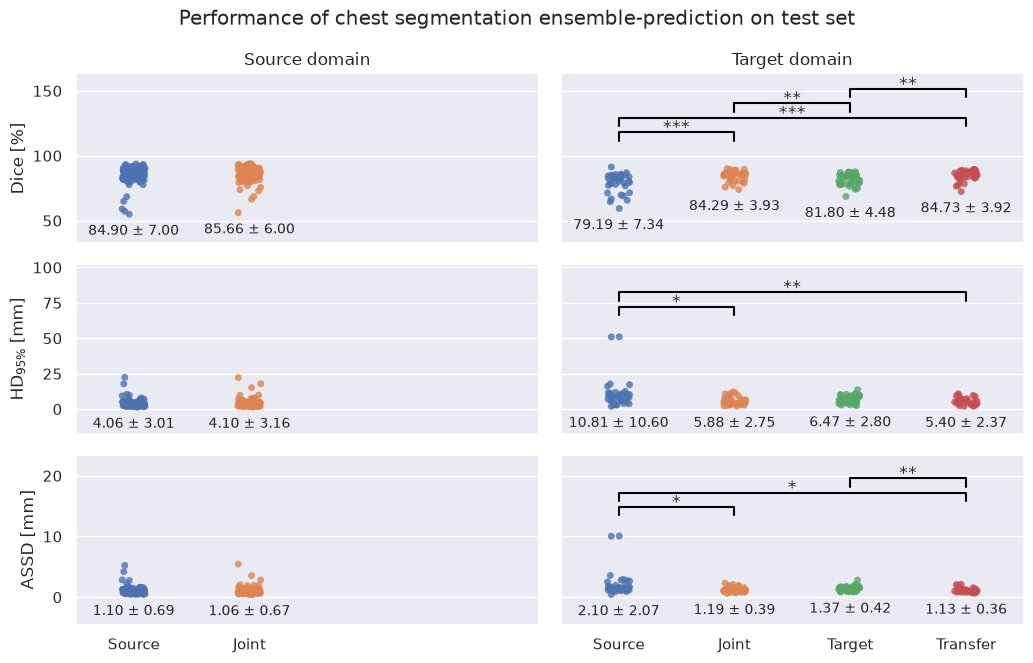

In [8]:
title = "Performance of chest segmentation ensemble-prediction on test set"
metric_cols = ["DICE_EP", "HD_EP", "ASSD_EP"]
y_lims = [(32.5, 163.5), (-17.5, 102.5), (-4.5, 23.5)]
plot_path = os.path.join(plot_dir, "chest_seg_metrics_EP.png")
plot_metrics(dfs, stats="lme")

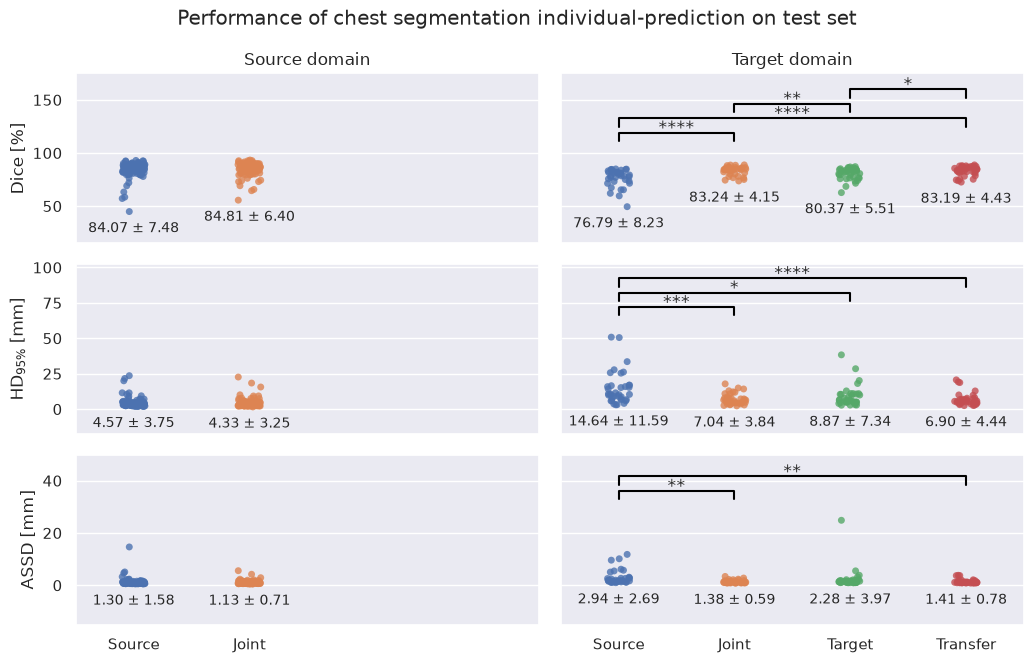

In [9]:
title = "Performance of chest segmentation individual-prediction on test set"
metric_cols = ["DICE_IP", "HD_IP", "ASSD_IP"]
y_lims = [(15, 175), (-17.5, 102.5), (-15, 50)]
plot_path = os.path.join(plot_dir, "chest_seg_metrics_IP.png")
plot_metrics(dfs, stats="lme")

In [10]:
# Transfer-ensemble vs. transfer-individual
metric_cols = ["DICE", "HD", "ASSD"]
print("Transfer-ensemble vs. Transfer-individual")
for metric_col in metric_cols:
    df_t = tgt_df[tgt_df[domain_col] == "Transfer"]
    y1 = df_t[metric_col + "_EP"]
    y2 = df_t[metric_col + "_IP"]
    stat, p = ttest_rel(y1, y2)
    stars = convert_pvalue_to_asterisks(p)
    if stars == "ns":
        continue
    print(metric_col, stars)

Transfer-ensemble vs. Transfer-individual
DICE **
HD **
ASSD **


In [11]:
# Inter-rater agreement
metric_cols = ["DICE", "HD", "ASSD"]
print("Inter-rater")
for metric_col in metric_cols:
    y = tgt_df[tgt_df[domain_col] == "Inter-Rater"][metric_col + "_IR"]
    mean = y.mean()
    std = y.std()
    print(rf"{metric_col}: {mean:.2f} ± {std:.2f}")

Inter-rater
DICE: 81.39 ± 7.73
HD: 6.61 ± 4.04
ASSD: 1.48 ± 0.88


In [12]:
# Transfer-ensemble vs. inter-rater.
metric_cols = ["DICE", "HD", "ASSD"]
print("Transfer-ensemble vs. Inter-rater")
for metric_col in metric_cols:
    df1 = tgt_df[tgt_df[domain_col] == "Transfer"].sort_values(groups_col)
    df2 = tgt_df[tgt_df[domain_col] == "Inter-Rater"].sort_values(groups_col)
    assert list(df1[groups_col]) == list(df2[groups_col]), (
        f"Subject mismatch between Transfer and Inter-Rater for {metric_col}."
    )
    y1 = df1[metric_col + "_EP"]
    y2 = df2[metric_col + "_IR"]
    stat, p = ttest_rel(y1, y2)
    stars = convert_pvalue_to_asterisks(p)
    if stars == "ns":
        continue
    print(metric_col, stars)

Transfer-ensemble vs. Inter-rater
DICE **
HD *
ASSD **


## 3. Heart segmentation networks comparison

Same four training conditions as Section 2 (no inter-rater comparison for this ROI). Additionally reports centre distance (CD) alongside Dice/HD95/ASSD.

In [13]:
metric_labels = ["Dice [%]", "HD$_{95\\%}$ [mm]", "ASSD [mm]"]
domain_col = "domain"
groups_col = "subject_id"

domains_src = ["philips", "joint_to_philips"]
domains_src_labels = ["Source", "Joint"]
comparisons_src = [("Source", "Joint")]

domains_tgt = ["philips_to_siemens", "joint_to_siemens", "siemens", "siemens_transfer"]
domains_tgt_labels = ["Source", "Joint", "Target", "Transfer"]
comparisons_tgt = [("Source", "Joint"), ("Source", "Target"), ("Source", "Transfer"),
                   ("Joint", "Target"), ("Joint", "Transfer"),
                   ("Target", "Transfer")]

domains = [domains_src, domains_tgt]
domains_labels = [domains_src_labels, domains_tgt_labels]
comparisons = [comparisons_src, comparisons_tgt]

In [14]:
src_df = load_df(csv_dir, domain_col, domains_src, domains_src_labels, roi="heart")
tgt_df = load_df(csv_dir, domain_col, domains_tgt, domains_tgt_labels, roi="heart")
dfs = [src_df, tgt_df]

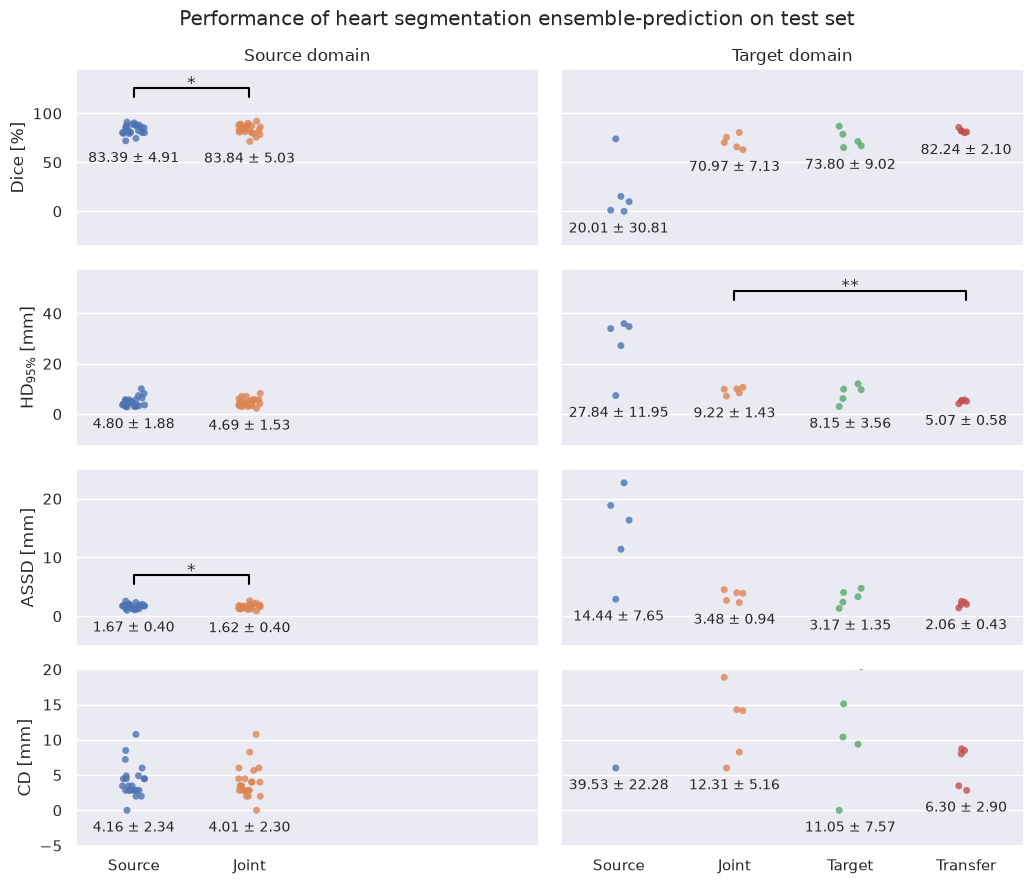

In [15]:
title = "Performance of heart segmentation ensemble-prediction on test set"
metric_labels = ["Dice [%]", "HD$_{95\\%}$ [mm]", "ASSD [mm]", "CD [mm]"]
metric_cols = ["DICE_EP", "HD_EP", "ASSD_EP", "CD_EP"]
y_lims = [(-35, 145), (-12.5, 57.5), (-5, 25), (-5, 20)]
plot_path = os.path.join(plot_dir, "heart_seg_metrics_EP.png")
plot_metrics(dfs, stats="ttest")

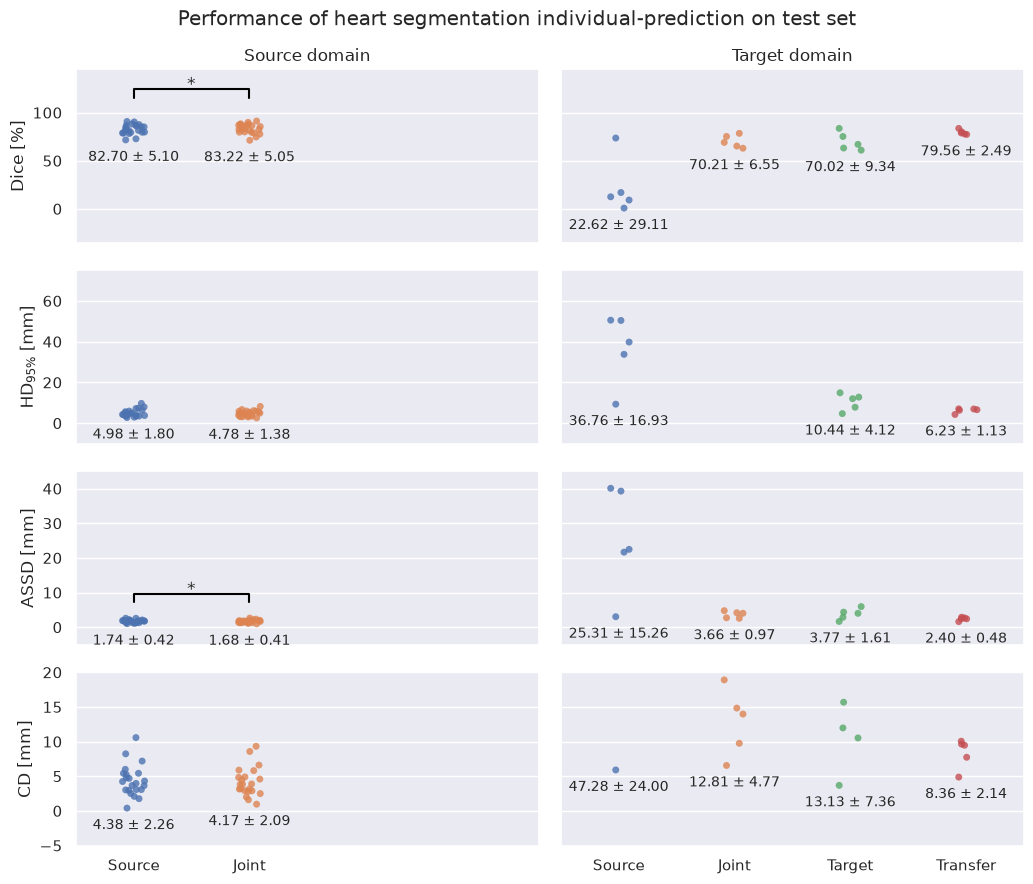

In [16]:
title = "Performance of heart segmentation individual-prediction on test set"
metric_cols = ["DICE_IP", "HD_IP", "ASSD_IP", "CD_IP"]
y_lims = [(-35, 145), (-10, 75), (-5, 45), (-5, 20)]
plot_path = os.path.join(plot_dir, "heart_seg_metrics_IP.png")
plot_metrics(dfs, stats="ttest")

In [17]:
# Transfer-ensemble vs. transfer-individual
metric_cols = ["DICE", "HD", "ASSD", "CD"]
print("Transfer-ensemble vs. Transfer-individual")
for metric_col in metric_cols:
    df_t = tgt_df[tgt_df[domain_col] == "Transfer"]
    y1 = df_t[metric_col + "_EP"]
    y2 = df_t[metric_col + "_IP"]
    stat, p = ttest_rel(y1, y2)
    stars = convert_pvalue_to_asterisks(p)
    if stars == "ns":
        continue
    print(metric_col, f"{p:.4f}", stars)

Transfer-ensemble vs. Transfer-individual
DICE 0.0014 **
HD 0.0274 *
ASSD 0.0010 ***
